# Do the pre-pandemic drivers of well-being still hold in the pandemic era?

**Data:** OECD *How's Life?* database — Current Well-being (`DSD_HSL@DF_HSL_CWB` v1.1) and Future Well-being (`DF_HSL_FWB`) dataflows, SDMX CSV exports with label columns.

**Research question:** Which structural and social indicators predicted cross-country differences in well-being before the pandemic (2013/2018), and do the same indicators still predict well-being in the pandemic era (2021/2022)?

**Outcomes (three constructs of well-being):**
- **Life satisfaction** — cognitive evaluation (Cantril ladder, 0–10)
- **Negative affect balance** — hedonic experience (% reporting negative emotions yesterday)
- **Deaths from suicide, alcohol, drugs** — behavioural/physical (register-based; breaks the shared-Gallup-source problem; modelled in logs)

**Design — the year split does double duty:**
1. *Statistical honesty:* indicators are screened by correlation on the 2013–18 window and the models are fit on the 2021–22 window, so the reported R² is not inflated by selecting predictors on the data they are evaluated against (no double-dipping / post-selection bias).
2. *Substantive question:* 2013/2018 are ordinary years; 2021/2022 are pandemic-era. If the screened pre-pandemic drivers fit poorly — or their coefficients shift — in 2021–22, that is a finding about the stability of well-being drivers under a systemic shock, not merely a validation failure. A pooled coefficient-stability (Chow-style) test makes this comparison formal.

**Phases**
1. Coverage + complement filters, applied over both windows jointly (same country set in both windows, so window differences are not confounded with sample composition)
2. Correlation screen (+ within-domain selection) on the 2013–18 country means
3. Parallel OLS models on the 2021–22 means — adjusted R², nested-block ΔR² F-test, VIFs, coefficient-stability test
4. Residual deep-dive on the fit window

**Provenance of quality flags:** `OBS_STATUS` follows the SDMX cross-domain codelist `CL_OBS_STATUS` **v2.2** (as served with this dataflow by the OECD SDMX registry: `https://sdmx.oecd.org/public/rest/dataflow/OECD.WISE.WDP/DSD_HSL@DF_HSL_CWB/1.1?references=codelist`). Key codes present in these files: A normal, D definition differs (footnote-type deviation), B time-series break, E estimated, P provisional, W includes data from another category. Standard reference: https://sdmx.org/sdmx_cdcl/

*This notebook consolidates `data_lab_v3.ipynb` (indicator screening) and `oecd_wellbeing_analysis.ipynb` (modelling); it supersedes the within-country longitudinal correlations of the former, which were unstable at the available sample sizes (2–8 overlapping years per country).*

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

CWB_PATH = "dataset current unfiltered taku.csv"   # Current well-being dataflow (DF_HSL_CWB)
FWB_PATH = "dataset future unfiltered taku.csv"    # Future well-being dataflow (DF_HSL_FWB)

SCREEN_YEARS = [2013, 2018]   # pre-pandemic window  -> Phase 2 screening
FIT_YEARS    = [2021, 2022]   # pandemic-era window  -> Phase 3 modelling

OUT_LS = "Life satisfaction"
OUT_NA = "Negative affect balance"
OUT_DD = "Deaths from suicide, alcohol, drugs"

N_PRED = 5          # predictor budget: set to 5 to mirror the 5-factor Maslow comparison arm
                    # (design-symmetry choice, not tuned on results; ~5-6 obs per parameter, at
                    #  the floor of the 5-10 observations-per-predictor rule)
MIN_COVERAGE = 0.8  # candidate must cover >=80% of the core countries in BOTH windows

## Phase 0 — Ingestion and Total-level filter

`AGE`, `SEX` and `EDUCATION_LEV` are filtered to `_T` (Total) **jointly and explicitly** before any reshaping. (In an earlier iteration, deduplicating without these filters silently kept female-only or education-specific rows for some series — e.g. Argentina's 2016 employment rate is 59.9% for women, 86.6% for men, 72.4% total.)

Measures reported in more than one unit at Total level are dropped rather than averaged across units. `OBS_STATUS` composition is reported so the share of break-flagged (B) and definition-differs (D) observations is on the record.

In [3]:
cwb_raw = pd.read_csv(CWB_PATH)
fwb_raw = pd.read_csv(FWB_PATH)

for name, df in [("CWB", cwb_raw), ("FWB", fwb_raw)]:
    print(f"{name}: {df.shape[0]:,} rows | {df['Measure'].nunique()} measures | "
          f"{df['REF_AREA'].nunique()} areas | {df['TIME_PERIOD'].min()}-{df['TIME_PERIOD'].max()}")
    print(f"  OBS_STATUS: {df['OBS_STATUS'].value_counts().to_dict()}")

def to_total(df):
    t = df[(df["AGE"] == "_T") & (df["SEX"] == "_T") & (df["EDUCATION_LEV"] == "_T")].copy()
    ambiguous = t.groupby("Measure")["UNIT_MEASURE"].nunique()
    ambiguous = ambiguous[ambiguous > 1].index.tolist()
    if ambiguous:
        print(f"  dropping measures reported in >1 unit: {ambiguous}")
        t = t[~t["Measure"].isin(ambiguous)]
    return t

cwb_t, fwb_t = to_total(cwb_raw), to_total(fwb_raw)
print(f"\nAfter Total-level filter: CWB {len(cwb_t):,} rows, FWB {len(fwb_t):,} rows")
share_bd = pd.concat([cwb_t, fwb_t])["OBS_STATUS"].isin(["B", "D"]).mean() * 100
print(f"Retained observations flagged B (series break) or D (definition differs): {share_bd:.1f}%")

CWB: 111,266 rows | 68 measures | 47 areas | 2004-2026
  OBS_STATUS: {'A': 101330, 'D': 7904, 'B': 1749, 'E': 165, 'P': 107, 'W': 11}
FWB: 37,858 rows | 35 measures | 48 areas | 2004-2026
  OBS_STATUS: {'A': 34094, 'D': 3141, 'B': 308, 'E': 162, 'P': 153}
  dropping measures reported in >1 unit: ['Carbon footprint']

After Total-level filter: CWB 27,995 rows, FWB 22,410 rows
Retained observations flagged B (series break) or D (definition differs): 2.6%


## Reshape: long → wide

One row per country × year, one column per measure; CWB and FWB merged side by side. Measure → domain and country-code → name lookups are built from the label columns.

In [4]:
def to_wide(t):
    return t.pivot_table(index=["REF_AREA", "TIME_PERIOD"], columns="Measure", values="OBS_VALUE")

cwb_w, fwb_w = to_wide(cwb_t), to_wide(fwb_t)
overlap = cwb_w.columns.intersection(fwb_w.columns)
if len(overlap):
    print(f"Measures present in both dataflows (kept from CWB): {list(overlap)}")
    fwb_w = fwb_w.drop(columns=list(overlap))
wide = pd.concat([cwb_w, fwb_w], axis=1)

meta = pd.concat([cwb_t[["Measure", "Domain"]], fwb_t[["Measure", "Domain"]]]).drop_duplicates("Measure")
DOMAIN = dict(zip(meta["Measure"], meta["Domain"]))
NAME = dict(pd.concat([cwb_raw, fwb_raw])[["REF_AREA", "Reference area"]].drop_duplicates().values)

print(f"Wide panel: {wide.shape[0]:,} country-year rows x {wide.shape[1]} measures")

Wide panel: 1,100 country-year rows x 102 measures


## Phase 1 — Coverage and complement filters, both windows jointly

Each window is collapsed to **country means** (Gallup-sourced variables typically contribute 1–2 observations per window, annual administrative variables up to 2; this is documented, not hidden).

- **Core sample:** countries with both survey outcomes (life satisfaction, negative affect) present in *both* windows — the same countries are screened and modelled, so the pre/post comparison is not confounded by sample composition.
- **Viable candidates:** every measure outside the Subjective well-being domain (outcomes must not sit in the predictor pool — this is also why deaths of despair is *removed from the screen*: it is an outcome now) with ≥80% coverage of the core sample in both windows.

In [5]:
def window_mean(years):
    sub = wide[wide.index.get_level_values("TIME_PERIOD").isin(years)]
    return sub.groupby(level="REF_AREA").mean()

scr, fit = window_mean(SCREEN_YEARS), window_mean(FIT_YEARS)

has = pd.DataFrame({
    "ls_scr": scr[OUT_LS].notna(),
    "na_scr": scr[OUT_NA].notna(),
    "ls_fit": fit[OUT_LS].reindex(scr.index).notna(),
    "na_fit": fit[OUT_NA].reindex(scr.index).notna(),
}).fillna(False)
core = has.index[has.all(axis=1)]
print(f"Core sample: {len(core)} countries with both survey outcomes in BOTH windows")
print(sorted(NAME.get(c, c) for c in core))

dd_n_scr = scr.loc[core, OUT_DD].notna().sum()
dd_n_fit = fit.loc[core, OUT_DD].notna().sum()
print(f"\nDeaths-of-despair coverage within core sample: screen {dd_n_scr}, fit {dd_n_fit}")

exclude = {m for m, d in DOMAIN.items() if d == "Subjective well-being"} | {OUT_DD}
candidates = [c for c in wide.columns if c not in exclude]

cov = pd.DataFrame({
    "scr_cov": scr.loc[core, candidates].notna().mean(),
    "fit_cov": fit.loc[core, candidates].notna().mean(),
})
viable = cov[(cov["scr_cov"] >= MIN_COVERAGE) & (cov["fit_cov"] >= MIN_COVERAGE)].index.tolist()
print(f"\nViable candidates (>= {MIN_COVERAGE:.0%} coverage of core sample in both windows): "
      f"{len(viable)} of {len(candidates)}")
cov_v = (cov.loc[viable]
         .assign(domain=[DOMAIN.get(v, "?") for v in viable])
         .sort_values(["domain", "scr_cov"], ascending=[True, False]))
print(cov_v.round(2).to_string())

Core sample: 33 countries with both survey outcomes in BOTH windows
['Austria', 'Belgium', 'Bulgaria', 'Canada', 'Colombia', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Netherlands', 'New Zealand', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovak Republic', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Türkiye', 'United Kingdom']

Deaths-of-despair coverage within core sample: screen 33, fit 30

Viable candidates (>= 80% coverage of core sample in both windows): 64 of 96
                                                                           scr_cov  fit_cov                 domain
Measure                                                                                                           
Gross fixed capital formation                                                 1.00     1.00       Economic capital
Total economy net financial worth                       

In [6]:
print(has.head())

          ls_scr  na_scr  ls_fit  na_fit
REF_AREA                                
ARG        False    True   False    True
AUS        False    True   False    True
AUT         True    True    True    True
BEL         True    True    True    True
BGR         True    True    True    True


In [7]:
print(scr.head())

Measure   Access to green space  Adult literacy skills  Adult numeracy skills  Adults with low numeracy skills  Average annual gross earnings  Deaths from suicide, alcohol, drugs  \
REF_AREA                                                                                                                                                                             
ARG                         NaN                    NaN                    NaN                              NaN                            NaN                            14.849253   
AUS                         NaN                    NaN                    NaN                              NaN                     69510.8105                            19.189590   
AUT                   77.252527                    NaN                    NaN                              NaN                     72650.9645                            21.042312   
BEL                   57.652810                    NaN                    NaN             

## Corrected Phase 2 and 3 Revised

In [8]:
# ==============================================================================
# PHASE 2 & 3 (REVISED): OUTCOME-SPECIFIC CORRELATION SCREEN & PARALLEL MODELS
# ==============================================================================

def fisher_ci(r, n):
    if n <= 3 or pd.isna(r) or abs(r) >= 1:
        return (np.nan, np.nan)
    z, se = np.arctanh(r), 1 / np.sqrt(n - 3)
    return tuple(np.tanh([z - 1.96 * se, z + 1.96 * se]))

def screen_and_select_predictors(scr_df, outcome_col, viable_candidates, domain_lookup, use_log=False, n_pred=5):
    """
    Performs cross-sectional Pearson correlation screening against a specific outcome 
    on the pre-pandemic window. Selects the top |r| predictor per domain, capped at n_pred overall.
    """
    y_scr = scr_df.loc[core, outcome_col]
    if use_log:
        y_scr = np.log(y_scr.where(y_scr > 0))
        
    rows = []
    for candidate in viable_candidates:
        valid_pairs = pd.concat([scr_df.loc[core, candidate], y_scr], axis=1).dropna()
        if len(valid_pairs) < 10:
            continue
        r = valid_pairs.iloc[:, 0].corr(valid_pairs.iloc[:, 1])
        ci_lo, ci_hi = fisher_ci(r, len(valid_pairs))
        rows.append({
            "indicator": candidate,
            "domain": domain_lookup.get(candidate, "?"),
            "n": len(valid_pairs),
            "r": r,
            "ci_lo": ci_lo,
            "ci_hi": ci_hi,
            "abs_r": abs(r)
        })
    
    screen_tbl = pd.DataFrame(rows).sort_values("abs_r", ascending=False).reset_index(drop=True)
    
    # Select top |r| per domain, then cap at top n_pred overall
    top_per_domain = screen_tbl.groupby("domain", sort=False).head(1)
    selected_preds = top_per_domain.nlargest(n_pred, "abs_r")["indicator"].tolist()
    
    return selected_preds, screen_tbl

def build_frame(wm, outcome_col, predictors, use_log=False):
    yv = wm[outcome_col]
    if use_log:
        yv = np.log(yv.where(yv > 0))
    return pd.concat([yv.rename("y"), wm[predictors]], axis=1).dropna()

def fit_z_ols(frame, predictors):
    Xz = (frame[predictors] - frame[predictors].mean()) / frame[predictors].std()
    return Xz, sm.OLS(frame["y"], sm.add_constant(Xz)).fit()


# --- Execution across the 3 distinct outcomes ---

OUTCOME_SPECS = [
    ("Life satisfaction (cognitive)", OUT_LS, False),
    ("Negative affect balance (hedonic)", OUT_NA, False),
    ("log Deaths of despair (behavioural)", OUT_DD, True),
]

outcome_results = {}

for label, out_col, use_log in OUTCOME_SPECS:
    # 1. Screen predictors specifically for THIS outcome on 2013-18 window
    selected_preds, screen_tbl = screen_and_select_predictors(
        scr, out_col, viable, DOMAIN, use_log=use_log, n_pred=N_PRED
    )
    
    # 2. Fit model on 2021-22 pandemic window
    fit_frame = build_frame(fit.loc[core], out_col, selected_preds, use_log=use_log)
    Xz_fit, m_fit = fit_z_ols(fit_frame, selected_preds)
    
    # 3. Fit benchmark model on 2013-18 screen window
    scr_frame = build_frame(scr.loc[core], out_col, selected_preds, use_log=use_log)
    Xz_scr, m_scr = fit_z_ols(scr_frame, selected_preds)
    
    # Store for evaluation
    outcome_results[label] = {
        "predictors": selected_preds,
        "screen_tbl": screen_tbl,
        "fit_model": m_fit,
        "scr_model": m_scr,
        "fit_frame": fit_frame,
        "scr_frame": scr_frame
    }
    
    # Print summary
    print("=" * 84)
    print(f"OUTCOME: {label}")
    print(f"Selected Predictors: {selected_preds}")
    print(f"Fit Window [2021-22]  |  n = {int(m_fit.nobs)}  |  adj R2 = {m_fit.rsquared_adj:.2f}")
    print(f"Screen Window [2013-18] Benchmark  |  adj R2 = {m_scr.rsquared_adj:.2f}")
    print("-" * 84)
    coefs = pd.DataFrame({
        "beta_1SD": m_fit.params, 
        "p": m_fit.pvalues,
        "ci_lo": m_fit.conf_int()[0], 
        "ci_hi": m_fit.conf_int()[1]
    }).drop(index="const")
    print(coefs.round(3).to_string())
    print("\n")

OUTCOME: Life satisfaction (cognitive)
Selected Predictors: ['Satisfaction with time use', 'Satisfaction with personal relationships', 'Inability to keep home adequately warm', 'Trust in others', 'Difficulty making ends meet']
Fit Window [2021-22]  |  n = 27  |  adj R2 = 0.85
Screen Window [2013-18] Benchmark  |  adj R2 = 0.87
------------------------------------------------------------------------------------
                                          beta_1SD      p  ci_lo  ci_hi
Satisfaction with time use                   0.148  0.212 -0.091  0.387
Satisfaction with personal relationships     0.293  0.004  0.105  0.481
Inability to keep home adequately warm      -0.101  0.174 -0.251  0.048
Trust in others                              0.153  0.023  0.024  0.282
Difficulty making ends meet                  0.048  0.526 -0.108  0.205


OUTCOME: Negative affect balance (hedonic)
Selected Predictors: ['Corruption', 'Satisfaction with time use', 'Difficulty making ends meet', 'Households 

In [9]:
# ==============================================================================
# CELL 1: MODEL FIT COMPARISON (R^2 AND ADJUSTED R^2)
# ==============================================================================

comp_rows = []

for label, out_col, use_log in OUTCOME_SPECS:
    m_fit = outcome_results[label]["fit_model"]
    m_scr = outcome_results[label]["scr_model"]
    
    comp_rows.append({
        "Outcome": label,
        "Screen R² (2013–18)": round(m_scr.rsquared, 3),
        "Screen Adj. R² (2013–18)": round(m_scr.rsquared_adj, 3),
        "Fit R² (2021–22)": round(m_fit.rsquared, 3),
        "Fit Adj. R² (2021–22)": round(m_fit.rsquared_adj, 3),
        "n (Fit)": int(m_fit.nobs)
    })

comparison_df = pd.DataFrame(comp_rows)
print("=== MODEL FIT COMPARISON ACROSS OUTCOMES ===")
print(comparison_df.to_string(index=False))

=== MODEL FIT COMPARISON ACROSS OUTCOMES ===
                            Outcome  Screen R² (2013–18)  Screen Adj. R² (2013–18)  Fit R² (2021–22)  Fit Adj. R² (2021–22)  n (Fit)
      Life satisfaction (cognitive)                0.896                     0.873             0.879                  0.850       27
  Negative affect balance (hedonic)                0.881                     0.855             0.698                  0.629       28
log Deaths of despair (behavioural)                0.639                     0.553             0.538                  0.402       23


In [11]:
# ==============================================================================
# CELL 2: CHOW TEST FOR STRUCTURAL STABILITY ACROSS WINDOWS
# ==============================================================================

def run_chow_test(scr_df, fit_df, outcome_col, predictors, use_log=False):
    """
    Pools screen (W=0) and fit (W=1) windows, adds interaction terms (predictor x W),
    and performs an ANOVA F-test comparing the constrained model vs full interaction model.
    """
    scr_fr = build_frame(scr_df, outcome_col, predictors, use_log).assign(W=0)
    fit_fr = build_frame(fit_df, outcome_col, predictors, use_log).assign(W=1)
    pool = pd.concat([scr_fr, fit_fr])
    
    # Standardize predictors within pooled sample
    Xz = (pool[predictors] - pool[predictors].mean()) / pool[predictors].std()
    
    # Restricted model: main effects + window dummy W
    X_res = sm.add_constant(pd.concat([Xz, pool["W"]], axis=1))
    
    # Full model: main effects + window dummy W + interaction terms
    X_full = X_res.copy()
    for p in predictors:
        X_full[p + " x W"] = Xz[p] * pool["W"]
        
    m_res = sm.OLS(pool["y"], X_res).fit()
    m_full = sm.OLS(pool["y"], X_full).fit()
    
    cmp = anova_lm(m_res, m_full)
    f_stat = cmp.iloc[1]["F"]
    p_val = cmp.iloc[1]["Pr(>F)"]
    
    return f_stat, p_val


chow_rows = []

for label, out_col, use_log in OUTCOME_SPECS:
    preds = outcome_results[label]["predictors"]
    f_stat, p_val = run_chow_test(scr.loc[core], fit.loc[core], out_col, preds, use_log)
    
    chow_rows.append({
        "Outcome": label,
        "F-statistic": round(f_stat, 3),
        "p-value": round(p_val, 3),
        "Structural Shift (α = 0.05)": "Significant Shift" if p_val < 0.05 else "Stable (No Shift)"
    })

chow_df = pd.DataFrame(chow_rows)
print("=== CHOW TEST FOR COEFFICIENT STABILITY ===")
print(chow_df.to_string(index=False))

=== CHOW TEST FOR COEFFICIENT STABILITY ===
                            Outcome  F-statistic  p-value Structural Shift (α = 0.05)
      Life satisfaction (cognitive)        1.030    0.412           Stable (No Shift)
  Negative affect balance (hedonic)        0.830    0.535           Stable (No Shift)
log Deaths of despair (behavioural)        0.343    0.883           Stable (No Shift)


In [12]:
MASLOW = {
    "Physiological": "Life expectancy at birth",
    "Safety": "Housing affordability",
    "Belonging": "Social support",
    "Esteem": "Employment rate",
    "Self-actualisation": "Volunteering through organisations",
}
MASLOW_PREDS = list(MASLOW.values())

                               Outcome                        Outcome_Short  DD_Scr_R2  DD_Scr_AdjR2  DD_Fit_R2  DD_Fit_AdjR2  DD_Fit_N  Maslow_Scr_R2  Maslow_Scr_AdjR2  Maslow_Fit_R2  \
0        Life satisfaction (cognitive)        Life satisfaction (cognitive)   0.895784      0.873128   0.878549      0.849632        27       0.550396          0.463934       0.399487   
1    Negative affect balance (hedonic)    Negative affect balance (hedonic)   0.881067      0.855212   0.697841      0.629168        28       0.870850          0.846014       0.601564   
2  log Deaths of despair (behavioural)  log Deaths of despair (behavioural)   0.639307      0.553428   0.537684      0.401708        23       0.291464          0.155207       0.347541   

   Maslow_Fit_AdjR2  Maslow_Fit_N  
0          0.288281            33  
1          0.527780            33  
2          0.211612            30  


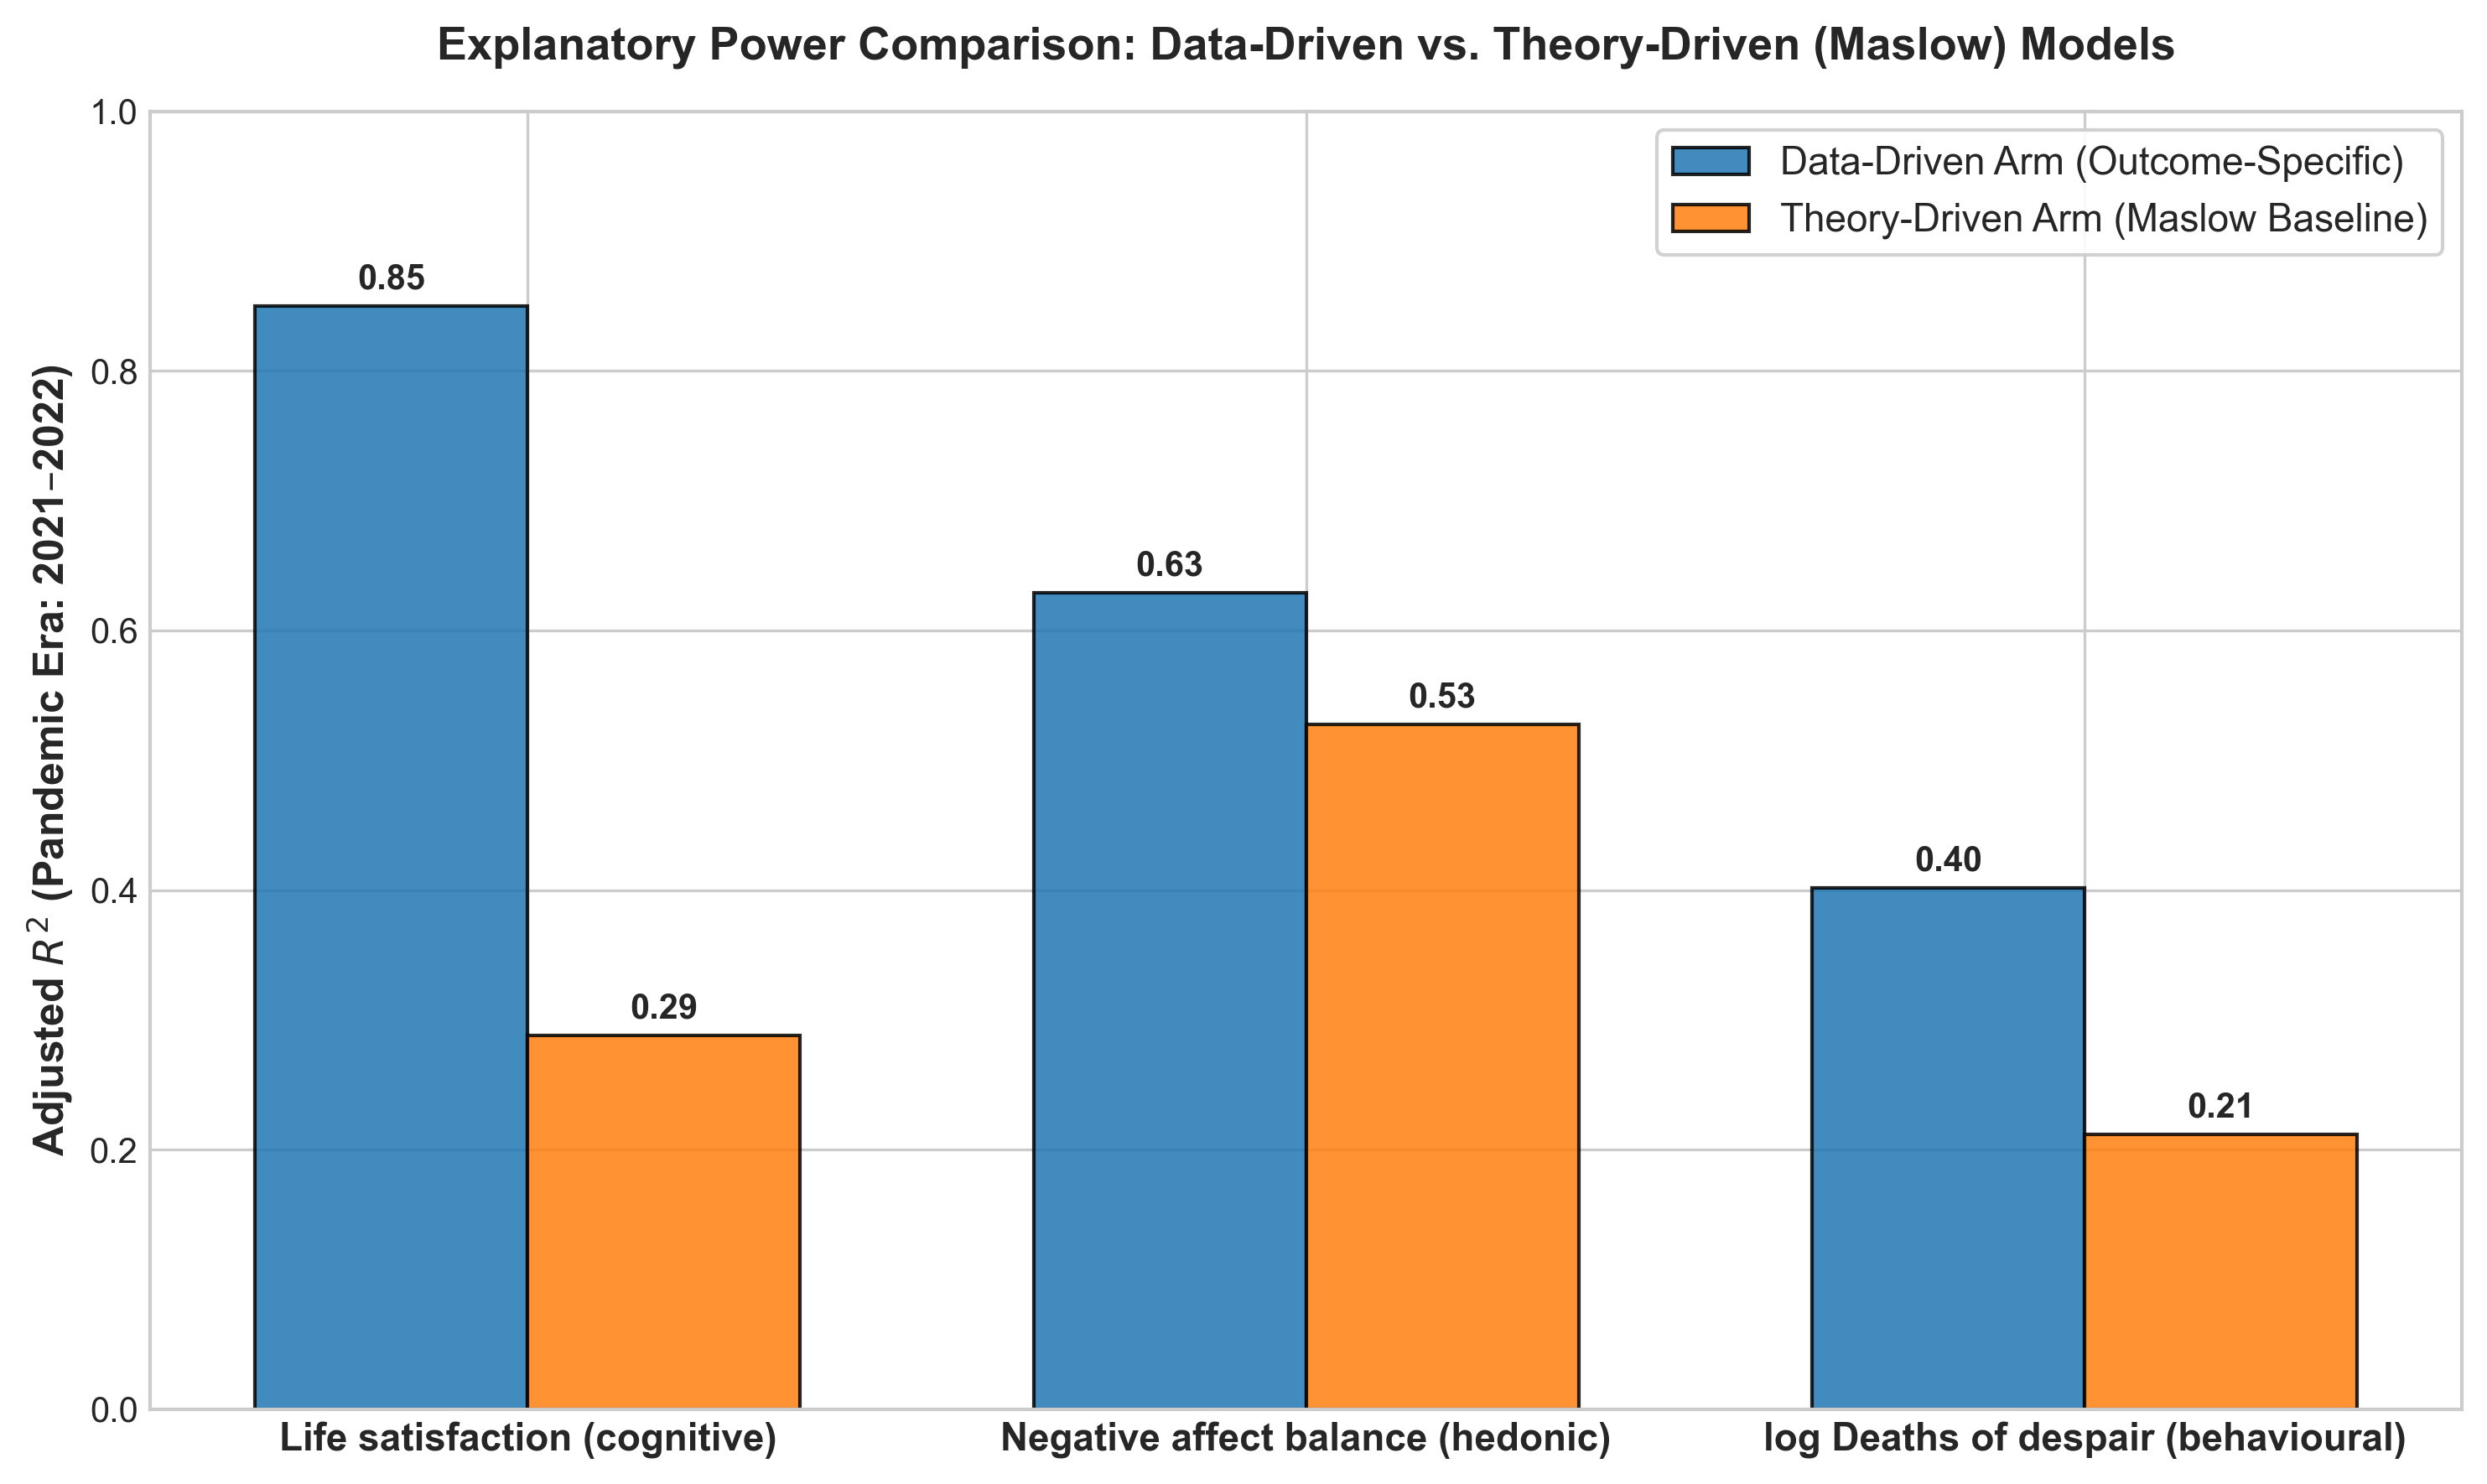

In [13]:
comparison_data = []

for label, out_col, use_log in OUTCOME_SPECS:
    # Data-driven predictors (outcome specific)
    dd_preds, _ = screen_and_select_predictors(
        scr, out_col, viable, DOMAIN, use_log=use_log, n_pred=N_PRED
    )
    
    # Fit data-driven
    _, m_dd_scr = fit_z_ols(build_frame(scr.loc[core], out_col, dd_preds, use_log), dd_preds)
    _, m_dd_fit = fit_z_ols(build_frame(fit.loc[core], out_col, dd_preds, use_log), dd_preds)
    
    # Fit Maslow
    _, m_mas_scr = fit_z_ols(build_frame(scr.loc[core], out_col, MASLOW_PREDS, use_log), MASLOW_PREDS)
    _, m_mas_fit = fit_z_ols(build_frame(fit.loc[core], out_col, MASLOW_PREDS, use_log), MASLOW_PREDS)
    
    comparison_data.append({
        "Outcome": label.replace("\n", " "),
        "Outcome_Short": label,
        "DD_Scr_R2": m_dd_scr.rsquared,
        "DD_Scr_AdjR2": m_dd_scr.rsquared_adj,
        "DD_Fit_R2": m_dd_fit.rsquared,
        "DD_Fit_AdjR2": m_dd_fit.rsquared_adj,
        "DD_Fit_N": int(m_dd_fit.nobs),
        "Maslow_Scr_R2": m_mas_scr.rsquared,
        "Maslow_Scr_AdjR2": m_mas_scr.rsquared_adj,
        "Maslow_Fit_R2": m_mas_fit.rsquared,
        "Maslow_Fit_AdjR2": m_mas_fit.rsquared_adj,
        "Maslow_Fit_N": int(m_mas_fit.nobs)
    })

df_comp = pd.DataFrame(comparison_data)
print(df_comp)

# Plotting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

x = np.arange(len(df_comp))
width = 0.35

rects1 = ax.bar(x - width/2, df_comp["DD_Fit_AdjR2"], width, label='Data-Driven Arm (Outcome-Specific)', color='#1f77b4', edgecolor='black', alpha=0.85)
rects2 = ax.bar(x + width/2, df_comp["Maslow_Fit_AdjR2"], width, label='Theory-Driven Arm (Maslow Baseline)', color='#ff7f0e', edgecolor='black', alpha=0.85)

ax.set_ylabel('Adjusted $R^2$ (Pandemic Era: 2021–2022)', fontsize=12, fontweight='bold')
ax.set_title('Explanatory Power Comparison: Data-Driven vs. Theory-Driven (Maslow) Models', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(df_comp["Outcome_Short"], fontsize=11, fontweight='semibold')
ax.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
ax.set_ylim(0, 1.0)

# Add values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
#plt.savefig("model_comparison_plot.png")
#plt.close()
#print("Plot saved as model_comparison_plot.png")

In [27]:
final_results = pd.DataFrame(
                    index = df_comp["Outcome"],
                    columns = ["Data-Driven R2", "Data-Driven AdjR2","Data-Driven N",
                               "Maslow R2", "Maslow AdjR2", "Maslow N"])

final_results["Data-Driven R2"] = df_comp["DD_Fit_R2"].values
final_results["Data-Driven AdjR2"] = df_comp["DD_Fit_AdjR2"].values
final_results["Data-Driven N"] = df_comp["DD_Fit_N"].values
final_results["Maslow R2"] = df_comp["Maslow_Fit_R2"].values
final_results["Maslow AdjR2"] = df_comp["Maslow_Fit_AdjR2"].values
final_results["Maslow N"] = df_comp["Maslow_Fit_N"].values

print(final_results)

                                     Data-Driven R2  Data-Driven AdjR2  Data-Driven N  Maslow R2  Maslow AdjR2  Maslow N
Outcome                                                                                                                 
Life satisfaction (cognitive)              0.878549           0.849632             27   0.399487      0.288281        33
Negative affect balance (hedonic)          0.697841           0.629168             28   0.601564      0.527780        33
log Deaths of despair (behavioural)        0.537684           0.401708             23   0.347541      0.211612        30


## Phase 2 — Correlation screen on the pre-pandemic window

Cross-sectional Pearson correlation of each viable candidate with **life satisfaction**, computed on 2013–18 country means, with 95% Fisher-z confidence intervals and per-pair n. Selection rule: top |r| within each domain (prevents stacking near-duplicates like an indicator and its deprivation-share complement), then the top `N_PRED` overall.

The screen is run against life satisfaction only; the same predictor set is then used for all three outcomes in Phase 3, so cross-outcome comparisons are like-for-like. Note the screen is *frozen here* — nothing downstream feeds back into selection.

In [ ]:
def fisher_ci(r, n):
    if n <= 3 or pd.isna(r) or abs(r) >= 1:
        return (np.nan, np.nan)
    z, se = np.arctanh(r), 1 / np.sqrt(n - 3)
    return tuple(np.tanh([z - 1.96 * se, z + 1.96 * se]))

y_scr = scr.loc[core, OUT_LS]
rows = []
for v in viable:
    ok = pd.concat([scr.loc[core, v], y_scr], axis=1).dropna()
    if len(ok) < 10:
        continue
    r = ok.iloc[:, 0].corr(ok.iloc[:, 1])
    lo, hi = fisher_ci(r, len(ok))
    rows.append({"indicator": v, "domain": DOMAIN.get(v, "?"), "n": len(ok),
                 "r": r, "ci_lo": lo, "ci_hi": hi})

screen_tbl = (pd.DataFrame(rows)
              .assign(abs_r=lambda d: d["r"].abs())
              .sort_values("abs_r", ascending=False)
              .reset_index(drop=True))
print(screen_tbl.drop(columns="abs_r").round(2).to_string(index=False))

top_per_domain = screen_tbl.groupby("domain", sort=False).head(1)
selected = top_per_domain.nlargest(N_PRED, "abs_r")["indicator"].tolist()
print(f"\nSelected predictors (top |r| per domain, capped at {N_PRED}):")
for s in selected:
    row = screen_tbl.set_index("indicator").loc[s]
    print(f"  {s}  [{row['domain']}]  r={row['r']:+.2f}  "
          f"(95% CI {row['ci_lo']:+.2f}..{row['ci_hi']:+.2f}, n={int(row['n'])})")

inter = scr.loc[core, selected].corr().abs()
hi_pairs = [(a, b, round(inter.loc[a, b], 2))
            for i, a in enumerate(selected) for b in selected[i + 1:]
            if inter.loc[a, b] > 0.8]
if hi_pairs:
    print("\nWARNING - highly collinear selected pair(s):", hi_pairs)

                                                                indicator                domain  n     r  ci_lo  ci_hi
                                               Satisfaction with time use     Work-life balance 29  0.91   0.83   0.96
                                 Satisfaction with personal relationships    Social connections 29  0.85   0.71   0.93
                   Top personal relationship satisfaction scores quintile    Social connections 28 -0.85  -0.93  -0.70
                                   Inability to keep home adequately warm               Housing 29 -0.84  -0.92  -0.68
                                                          Trust in others        Social capital 30  0.81   0.64   0.91
                             Satisfaction with time use score less than 5     Work-life balance 28 -0.80  -0.90  -0.61
                                              Difficulty making ends meet     Income and wealth 31 -0.79  -0.89  -0.61
               Satisfaction with personal relati

## Phase 3 — Parallel models on the pandemic-era window

Same `N_PRED` screened predictors, three outcomes, 2021–22 country means. Predictors are z-standardised within each estimation sample, so a coefficient is the effect of a 1 SD cross-country difference. Deaths of despair is modelled as log(rate).

Below the pandemic-era models, the **same specification is refit on the screen window** as a benchmark. Because the predictors were *selected* on that window, its R² is optimistic by construction — the informative comparison is the *drop* from benchmark to fit window: a modest drop suggests the drivers transferred; a collapse suggests either pandemic disruption or screen overfitting (the coefficient-stability test below helps separate the two).

In [ ]:
def build_frame(wm, out_col, use_log=False):
    yv = wm[out_col]
    if use_log:
        yv = np.log(yv.where(yv > 0))
    return pd.concat([yv.rename("y"), wm[selected]], axis=1).dropna()

def zfit(frame):
    Xz = (frame[selected] - frame[selected].mean()) / frame[selected].std()
    return Xz, sm.OLS(frame["y"], sm.add_constant(Xz)).fit()

OUTCOME_SPECS = [
    ("Life satisfaction (cognitive)", OUT_LS, False),
    ("Negative affect balance (hedonic)", OUT_NA, False),
    ("log Deaths of despair (behavioural)", OUT_DD, True),
]

models, samples = {}, {}
for label, out_col, use_log in OUTCOME_SPECS:
    frame = build_frame(fit.loc[core], out_col, use_log)
    Xz, m = zfit(frame)
    models[label], samples[label] = m, frame
    print("=" * 84)
    print(f"{label}  |  fit window {FIT_YEARS}  |  n = {int(m.nobs)}  |  "
          f"adj R2 = {m.rsquared_adj:.2f}")
    coefs = pd.DataFrame({"beta_1SD": m.params, "p": m.pvalues,
                          "ci_lo": m.conf_int()[0], "ci_hi": m.conf_int()[1]}).drop(index="const")
    print(coefs.round(3).to_string())
    print()

print("=" * 84)
print(f"Benchmark: same specification on the SCREEN window {SCREEN_YEARS} "
      "(in-sample for the selection -> optimistic by construction)")
for label, out_col, use_log in OUTCOME_SPECS:
    frame_b = build_frame(scr.loc[core], out_col, use_log)
    _, mb = zfit(frame_b)
    m_fit = models[label]
    print(f"  {label:38s} screen adj R2 = {mb.rsquared_adj:5.2f} (n={int(mb.nobs)})   "
          f"fit adj R2 = {m_fit.rsquared_adj:5.2f} (n={int(m_fit.nobs)})")

Life satisfaction (cognitive)  |  fit window [2021, 2022]  |  n = 27  |  adj R2 = 0.85
                                          beta_1SD      p  ci_lo  ci_hi
Satisfaction with time use                   0.148  0.212 -0.091  0.387
Satisfaction with personal relationships     0.293  0.004  0.105  0.481
Inability to keep home adequately warm      -0.101  0.174 -0.251  0.048
Trust in others                              0.153  0.023  0.024  0.282
Difficulty making ends meet                  0.048  0.526 -0.108  0.205

Negative affect balance (hedonic)  |  fit window [2021, 2022]  |  n = 27  |  adj R2 = 0.49
                                          beta_1SD      p  ci_lo  ci_hi
Satisfaction with time use                  -3.969  0.076 -8.393  0.454
Satisfaction with personal relationships     0.631  0.710 -2.853  4.115
Inability to keep home adequately warm       1.475  0.280 -1.293  4.243
Trust in others                             -0.709  0.544 -3.100  1.682
Difficulty making ends meet  

### Collinearity and nested-block ΔR²

VIFs on the life-satisfaction sample; then a nested-block F-test per outcome — material block (Income & wealth / Work & job quality / Housing domains) first, social/contextual block added on top. The ΔR² F-test asks whether the non-material indicators explain variance *beyond* material conditions.

In [ ]:
frame = samples["Life satisfaction (cognitive)"]
Xz = (frame[selected] - frame[selected].mean()) / frame[selected].std()
Xc = sm.add_constant(Xz)
vifs = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
                 index=selected)
print("VIF (life-satisfaction estimation sample):")
print(vifs.round(2).to_string())

MATERIAL = {"Income and wealth", "Work and job quality", "Housing"}
block1 = [p for p in selected if DOMAIN.get(p) in MATERIAL]
block2 = [p for p in selected if p not in block1]
print(f"\nBlock 1 (material):          {block1}")
print(f"Block 2 (social/contextual): {block2}")

if block1 and block2:
    for label, m in models.items():
        f = samples[label]
        Xz = (f[selected] - f[selected].mean()) / f[selected].std()
        m1 = sm.OLS(f["y"], sm.add_constant(Xz[block1])).fit()
        m2 = sm.OLS(f["y"], sm.add_constant(Xz)).fit()
        cmp = anova_lm(m1, m2)
        print(f"\n{label}:")
        print(f"  material-only adj R2 = {m1.rsquared_adj:.2f}  ->  full adj R2 = {m2.rsquared_adj:.2f}"
              f"   |   dR2 F = {cmp.iloc[1]['F']:.2f}, p = {cmp.iloc[1]['Pr(>F)']:.3f}")
else:
    print("\nNested-block test skipped: all selected predictors fall in one block.")

VIF (life-satisfaction estimation sample):
Satisfaction with time use                  6.29
Satisfaction with personal relationships    3.91
Inability to keep home adequately warm      2.46
Trust in others                             1.84
Difficulty making ends meet                 2.70

Block 1 (material):          ['Inability to keep home adequately warm', 'Difficulty making ends meet']
Block 2 (social/contextual): ['Satisfaction with time use', 'Satisfaction with personal relationships', 'Trust in others']

Life satisfaction (cognitive):
  material-only adj R2 = 0.53  ->  full adj R2 = 0.85   |   dR2 F = 17.77, p = 0.000

Negative affect balance (hedonic):
  material-only adj R2 = 0.36  ->  full adj R2 = 0.49   |   dR2 F = 3.04, p = 0.051

log Deaths of despair (behavioural):
  material-only adj R2 = -0.01  ->  full adj R2 = 0.26   |   dR2 F = 3.85, p = 0.025


### Coefficient-stability test — the formal answer to the research question

Comparing two separately-fit R² values is suggestive but weak. The direct test of "do pre-pandemic drivers still hold" is whether the *coefficients* changed: pool both windows, add a pandemic-era dummy `W` and predictor × `W` interactions, and F-test the interactions jointly (Chow-style).

*Caveat:* each country contributes an observation to both windows, so observations are not independent and these p-values are heuristic. A cluster-robust (by country) version is an open item.

In [ ]:
print("H0: pre-pandemic coefficients unchanged in 2021-22 (predictor x W interactions jointly zero)\n")
for label, out_col, use_log in OUTCOME_SPECS:
    parts = []
    for wm, flag in [(scr.loc[core], 0), (fit.loc[core], 1)]:
        f = build_frame(wm, out_col, use_log).assign(W=flag)
        parts.append(f)
    pool = pd.concat(parts)
    Xz = (pool[selected] - pool[selected].mean()) / pool[selected].std()
    X_res = sm.add_constant(pd.concat([Xz, pool["W"]], axis=1))
    X_full = X_res.copy()
    for p in selected:
        X_full[p + " x W"] = Xz[p] * pool["W"]
    m_res = sm.OLS(pool["y"], X_res).fit()
    m_full = sm.OLS(pool["y"], X_full).fit()
    cmp = anova_lm(m_res, m_full)
    print(f"  {label:38s} n_pooled = {len(pool):3d}   "
          f"interaction F = {cmp.iloc[1]['F']:.2f}, p = {cmp.iloc[1]['Pr(>F)']:.3f}")

H0: pre-pandemic coefficients unchanged in 2021-22 (predictor x W interactions jointly zero)

  Life satisfaction (cognitive)          n_pooled =  56   interaction F = 1.03, p = 0.412
  Negative affect balance (hedonic)      n_pooled =  56   interaction F = 0.77, p = 0.576
  log Deaths of despair (behavioural)    n_pooled =  55   interaction F = 0.12, p = 0.988


## Phase 4 — Residual deep-dive (fit window)

Countries the pandemic-era life-satisfaction model over/under-predicts, and whether the misses correlate with viable indicators held out of the model. |r| > 0.35 is "worth discussing", not proof (n ≈ 25–30).

OVER-performers (more satisfied than pandemic-era conditions predict):
   country    y  fitted  resid
    Greece 6.75    6.46   0.29
Luxembourg 7.32    7.03   0.28
     Italy 7.17    6.94   0.23
   Austria 7.94    7.73   0.20
   Romania 7.68    7.49   0.19

UNDER-performers (less satisfied than predicted):
 country    y  fitted  resid
  Latvia 6.79    7.45  -0.66
Portugal 6.97    7.24  -0.27
 Hungary 6.70    6.96  -0.26
 Ireland 7.35    7.61  -0.26
Bulgaria 5.61    5.77  -0.16


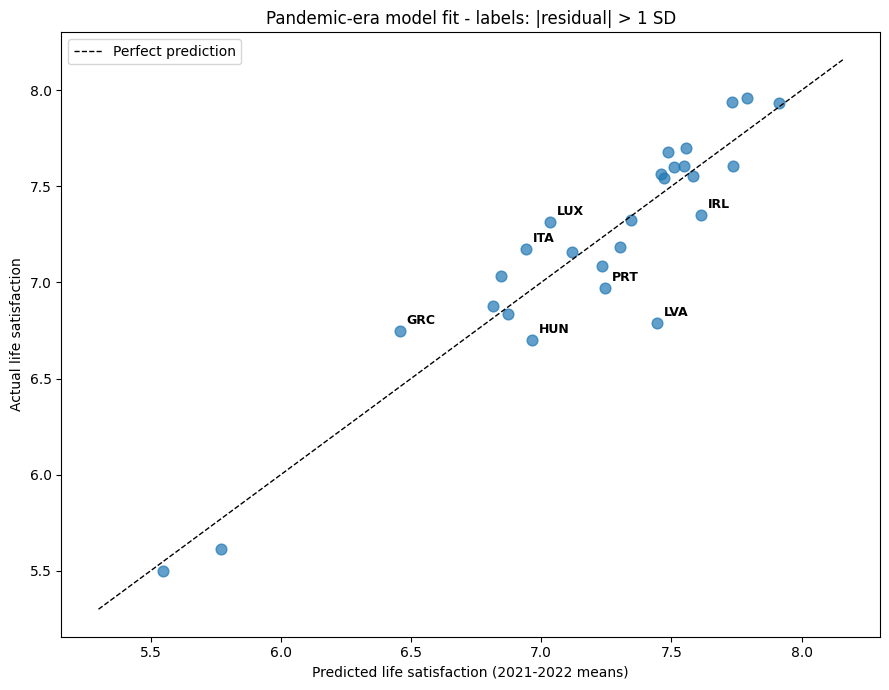

In [ ]:
m = models["Life satisfaction (cognitive)"]
resid_frame = samples["Life satisfaction (cognitive)"].copy()
resid_frame["fitted"] = m.fittedvalues
resid_frame["resid"] = m.resid
resid_frame["country"] = [NAME.get(c, c) for c in resid_frame.index]

show = ["country", "y", "fitted", "resid"]
print("OVER-performers (more satisfied than pandemic-era conditions predict):")
print(resid_frame.nlargest(5, "resid")[show].round(2).to_string(index=False))
print("\nUNDER-performers (less satisfied than predicted):")
print(resid_frame.nsmallest(5, "resid")[show].round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(resid_frame["fitted"], resid_frame["y"], s=60, alpha=0.7)
lims = [resid_frame[["fitted", "y"]].min().min() - 0.2,
        resid_frame[["fitted", "y"]].max().max() + 0.2]
ax.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
thr = resid_frame["resid"].std()
for c, r in resid_frame.iterrows():
    if abs(r["resid"]) > thr:
        ax.annotate(c, (r["fitted"], r["y"]), fontsize=9, fontweight="bold",
                    xytext=(5, 5), textcoords="offset points")
ax.set_xlabel(f"Predicted life satisfaction ({FIT_YEARS[0]}-{FIT_YEARS[1]} means)")
ax.set_ylabel("Actual life satisfaction")
ax.set_title("Pandemic-era model fit - labels: |residual| > 1 SD")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
held_out = [v for v in viable if v not in selected]
rows = []
for v in held_out:
    ok = pd.concat([fit.loc[core, v], resid_frame["resid"]], axis=1).dropna()
    if len(ok) < 10:
        continue
    rows.append({"indicator": v, "domain": DOMAIN.get(v, "?"), "n": len(ok),
                 "r_with_resid": ok.iloc[:, 0].corr(ok.iloc[:, 1])})
resid_tbl = (pd.DataFrame(rows)
             .assign(a=lambda d: d["r_with_resid"].abs())
             .sort_values("a", ascending=False)
             .drop(columns="a"))
print("Held-out indicators vs life-satisfaction residuals (top 12 by |r|):")
print(resid_tbl.head(12).round(2).to_string(index=False))

Held-out indicators vs life-satisfaction residuals (top 12 by |r|):
                                                      indicator               domain  n  r_with_resid
                                   Perceived health as negative               Health 27         -0.46
                                            Premature mortality        Human capital 26         -0.45
                                   Perceived health as positive               Health 27          0.43
                                                      Homicides               Safety 26         -0.42
Households and NPISHs net adjusted disposable income per capita    Income and wealth 26          0.42
                                  Gross fixed capital formation     Economic capital 27          0.41
                     Top earnings of full-time employees decile Work and job quality 26         -0.41
                                                Gender wage gap Work and job quality 27         -0.39
              

## Phase 2′ — Theory-driven arm: Maslow's hierarchy of needs

The comparison arm selects five indicators **a priori by theory** [7], one per level of Maslow's hierarchy, using the same cleaned panel, core sample and windows as the data-driven arm. The mapping is fixed here, before any Maslow-arm model is run, and is justified theoretically — not by the indicators' correlations:

| Maslow level | Indicator | Rationale |
|---|---|---|
| Physiological | Life expectancy at birth | basic bodily needs met at population scale |
| Safety | Housing affordability | secure shelter; income left after housing costs |
| Belonging | Social support | having someone to count on |
| Esteem | Employment rate | status, recognition and achievement through work |
| Self-actualisation | Volunteering through organisations | purpose beyond the self: an act not aimed at self-improvement and not motivated by monetary reward |

Note the two arms share **no indicators**, and the Maslow set is more heavily register/administrative (life expectancy, employment, affordability) where the screened set is survey-perception based — so the comparison also doubles as a partial check on common-source inflation in the screened arm's R².

In [ ]:
MASLOW = {
    "Physiological": "Life expectancy at birth",
    "Safety": "Housing affordability",
    "Belonging": "Social support",
    "Esteem": "Employment rate",
    "Self-actualisation": "Volunteering through organisations",
}
maslow = list(MASLOW.values())
assert all(m in wide.columns for m in maslow), "Maslow indicator missing from panel"
cov_m = pd.DataFrame({"scr_cov": scr.loc[core, maslow].notna().mean().round(2),
                      "fit_cov": fit.loc[core, maslow].notna().mean().round(2)})
print("Coverage of core sample (both windows):")
print(cov_m.to_string())

def build_frame_p(wm, out_col, preds, use_log=False):
    yv = wm[out_col]
    if use_log:
        yv = np.log(yv.where(yv > 0))
    return pd.concat([yv.rename("y"), wm[preds]], axis=1).dropna()

def zfit_p(frame, preds):
    Xz = (frame[preds] - frame[preds].mean()) / frame[preds].std()
    return Xz, sm.OLS(frame["y"], sm.add_constant(Xz)).fit()

maslow_models = {}
for label, out_col, use_log in OUTCOME_SPECS:
    fr = build_frame_p(fit.loc[core], out_col, maslow, use_log)
    Xz, m = zfit_p(fr, maslow)
    maslow_models[label] = m
    print("=" * 84)
    print(f"MASLOW ARM | {label}  |  fit window {FIT_YEARS}  |  n = {int(m.nobs)}  |  "
          f"adj R2 = {m.rsquared_adj:.2f}")
    coefs = pd.DataFrame({"beta_1SD": m.params, "p": m.pvalues}).drop(index="const")
    coefs.index = [f"{lvl}: {ind}" for lvl, ind in MASLOW.items()]
    print(coefs.round(3).to_string())
    print()

fr = build_frame_p(fit.loc[core], OUT_LS, maslow)
Xz, _ = zfit_p(fr, maslow)
Xc = sm.add_constant(Xz)
vifs_m = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
                   index=maslow)
print("VIF (Maslow arm, life-satisfaction sample):")
print(vifs_m.round(2).to_string())

Coverage of core sample (both windows):
                                    scr_cov  fit_cov
Measure                                             
Life expectancy at birth               1.00      1.0
Housing affordability                  0.97      1.0
Social support                         1.00      1.0
Employment rate                        1.00      1.0
Volunteering through organisations     1.00      1.0
MASLOW ARM | Life satisfaction (cognitive)  |  fit window [2021, 2022]  |  n = 33  |  adj R2 = 0.29
                                                        beta_1SD      p
Physiological: Life expectancy at birth                    0.104  0.368
Safety: Housing affordability                             -0.071  0.468
Belonging: Social support                                  0.002  0.987
Esteem: Employment rate                                    0.140  0.311
Self-actualisation: Volunteering through organisations     0.210  0.107

MASLOW ARM | Negative affect balance (hedonic)  |  fit w

In [ ]:
# ==============================================================================
# CELL 1: MODEL FIT COMPARISON (R^2 AND ADJUSTED R^2)
# ==============================================================================

comp_rows = []

for label, out_col, use_log in OUTCOME_SPECS:
    m_fit = outcome_results[label]["fit_model"]
    m_scr = outcome_results[label]["scr_model"]
    
    comp_rows.append({
        "Outcome": label,
        "Screen R² (2013–18)": round(m_scr.rsquared, 3),
        "Screen Adj. R² (2013–18)": round(m_scr.rsquared_adj, 3),
        "Fit R² (2021–22)": round(m_fit.rsquared, 3),
        "Fit Adj. R² (2021–22)": round(m_fit.rsquared_adj, 3),
        "n (Fit)": int(m_fit.nobs)
    })

comparison_df = pd.DataFrame(comp_rows)
print("=== MODEL FIT COMPARISON ACROSS OUTCOMES ===")
print(comparison_df.to_string(index=False))

### Head-to-head: data-driven vs theory-driven arms

Same outcomes, same windows, same core sample, same model form. Caveat on reading the screen-window column: for the **screened** arm it is in-sample for the selection (optimistic by construction); for the **Maslow** arm theory chose the indicators, so its screen-window fit carries no selection bias — the fairest single comparison is the fit-window column.

In [ ]:
def chow_p(preds, out_col, use_log):
    parts = []
    for wm, flag in [(scr.loc[core], 0), (fit.loc[core], 1)]:
        parts.append(build_frame_p(wm, out_col, preds, use_log).assign(W=flag))
    pool = pd.concat(parts)
    Xz = (pool[preds] - pool[preds].mean()) / pool[preds].std()
    X_res = sm.add_constant(pd.concat([Xz, pool["W"]], axis=1))
    X_full = X_res.copy()
    for p in preds:
        X_full[p + " x W"] = Xz[p] * pool["W"]
    m_res = sm.OLS(pool["y"], X_res).fit()
    m_full = sm.OLS(pool["y"], X_full).fit()
    cmp = anova_lm(m_res, m_full)
    return cmp.iloc[1]["F"], cmp.iloc[1]["Pr(>F)"]

rows = []
for label, out_col, use_log in OUTCOME_SPECS:
    for arm, preds in [("Screened", selected), ("Maslow", maslow)]:
        _, m_s = zfit_p(build_frame_p(scr.loc[core], out_col, preds, use_log), preds)
        _, m_f = zfit_p(build_frame_p(fit.loc[core], out_col, preds, use_log), preds)
        F, p = chow_p(preds, out_col, use_log)
        rows.append({"outcome": label, "arm": arm,
                     "adjR2_screen": round(m_s.rsquared_adj, 2),
                     "adjR2_fit": round(m_f.rsquared_adj, 2),
                     "n_fit": int(m_f.nobs), "stability_p": round(p, 3)})
comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))
print("\nIndicator overlap between the two arms:",
      sorted(set(selected) & set(maslow)) or "none")

                            outcome      arm  adjR2_screen  adjR2_fit  n_fit  stability_p
      Life satisfaction (cognitive) Screened          0.87       0.85     27        0.412
      Life satisfaction (cognitive)   Maslow          0.46       0.29     33        0.890
  Negative affect balance (hedonic) Screened          0.73       0.49     27        0.576
  Negative affect balance (hedonic)   Maslow          0.85       0.53     33        0.888
log Deaths of despair (behavioural) Screened         -0.01       0.26     26        0.988
log Deaths of despair (behavioural)   Maslow          0.16       0.21     30        0.843

Indicator overlap between the two arms: none


## Phase 4b — Outlier anatomy: Latvia and Greece

Classic influence diagnostics on the pandemic-era life-satisfaction model, in the standard order:
**studentized (jackknife) residuals** with a Bonferroni outlier test (is the deviation statistically surprising?),
**leverage** (is the country unusual in predictor space?),
**Cook's distance / DFBETAs** (does deleting it change the fit or a coefficient?),
then the follow-ups the diagnostics point to: a **contribution decomposition**, an **added-variable check** for the omitted factor the residuals implicated (perceived health), and a **leave-one-out sensitivity** on the coefficient the DFBETAs flag.

In [ ]:
m_ls = models["Life satisfaction (cognitive)"]
f_ls = samples["Life satisfaction (cognitive)"]
infl = m_ls.get_influence()
diag = pd.DataFrame({
    "resid": m_ls.resid.round(2),
    "student_t": infl.resid_studentized_external.round(2),
    "leverage": infl.hat_matrix_diag.round(2),
    "cooksD": infl.cooks_distance[0].round(2),
    "bonf_p": m_ls.outlier_test()["bonf(p)"].round(3),
}, index=f_ls.index)
n, k = len(f_ls), len(selected)
print(f"Influence diagnostics (|t|>2 notable; leverage > {2*(k+1)/n:.2f}; Cook's D > {4/n:.2f}):")
print(diag.reindex(diag["student_t"].abs().sort_values(ascending=False).index).head(6).to_string())

dfb = pd.DataFrame(infl.dfbetas, index=f_ls.index, columns=["const"] + selected)
print("\nDFBETAs for LVA and GRC (coefficient shift in SEs if the country is dropped):")
print(dfb.loc[["LVA", "GRC"]].round(2).T.to_string())

print("\nContribution decomposition (predictor z-value x beta):")
Xz_ls = (f_ls[selected] - f_ls[selected].mean()) / f_ls[selected].std()
for c in ["LVA", "GRC"]:
    print(f"\n{c}: observed {f_ls.loc[c,'y']:.2f} | predicted {m_ls.fittedvalues[c]:.2f} "
          f"| residual {m_ls.resid[c]:+.2f}")
    for p in selected:
        print(f"  {p:45s} z = {Xz_ls.loc[c,p]:+.2f} -> {m_ls.params[p]*Xz_ls.loc[c,p]:+.3f}")

Influence diagnostics (|t|>2 notable; leverage > 0.44; Cook's D > 0.15):
          resid  student_t  leverage  cooksD  bonf_p
REF_AREA                                            
LVA       -0.66      -3.82      0.10    0.17   0.029
GRC        0.29       2.94      0.76    3.27   0.216
LUX        0.28       1.40      0.22    0.09   1.000
PRT       -0.27      -1.40      0.28    0.12   1.000
IRL       -0.26      -1.27      0.19    0.06   1.000
HUN       -0.26      -1.22      0.12    0.03   1.000

DFBETAs for LVA and GRC (coefficient shift in SEs if the country is dropped):
REF_AREA                                   LVA   GRC
const                                    -0.78  1.15
Satisfaction with time use               -0.84  0.04
Satisfaction with personal relationships  0.53  1.24
Inability to keep home adequately warm    0.23 -0.92
Trust in others                           0.09 -0.63
Difficulty making ends meet              -0.78  4.11

Contribution decomposition (predictor z-value x beta

In [ ]:
# Follow-up 1: added-variable check — does perceived health absorb Latvia's miss?
plus = selected + ["Perceived health as positive"]
fr6 = build_frame_p(fit.loc[core], OUT_LS, plus)
_, m6 = zfit_p(fr6, plus)
print(f"Latvia residual, 5-predictor model:  {m_ls.resid['LVA']:+.2f}")
print(f"Latvia residual, + perceived health: {m6.resid['LVA']:+.2f}")
print(f"perceived-health beta (1 SD) = {m6.params['Perceived health as positive']:+.3f}, "
      f"p = {m6.pvalues['Perceived health as positive']:.3f}; "
      f"adj R2 {m_ls.rsquared_adj:.2f} -> {m6.rsquared_adj:.2f}")
print(f"(context: perceived health, fit-window mean {fit.loc[core,'Perceived health as positive'].mean():.0f}% "
      f"positive; LVA = {fit.loc['LVA','Perceived health as positive']:.0f}%, "
      f"lowest in the core sample)")

# Follow-up 2: leave-one-out sensitivity — Greece and the ends-meet coefficient
fG = f_ls.drop(index="GRC")
XzG = (fG[selected] - fG[selected].mean()) / fG[selected].std()
mG = sm.OLS(fG["y"], sm.add_constant(XzG)).fit()
p = "Difficulty making ends meet"
print(f"\n'{p}':")
print(f"  with Greece    beta = {m_ls.params[p]:+.3f} (p = {m_ls.pvalues[p]:.2f})")
print(f"  without Greece beta = {mG.params[p]:+.3f} (p = {mG.pvalues[p]:.2f})")
print(f"  adj R2 without Greece: {mG.rsquared_adj:.2f}")
print("\nReading: Greece's extreme economic strain (z = +3.8, highest leverage in the "
      "sample, Cook's D = 3.3) single-handedly sets — and sign-flips — the ends-meet "
      "coefficient. Its 'over-performance' is a high-leverage extrapolation effect, "
      "not a significant outlier (Bonferroni p = 0.22). Latvia is the opposite case: "
      "ordinary conditions (leverage 0.10), significantly lower satisfaction than "
      "predicted (Bonferroni p = 0.03) — a genuine response outlier, roughly 40% "
      "attributable to the omitted health dimension.")

Latvia residual, 5-predictor model:  -0.66
Latvia residual, + perceived health: -0.38
perceived-health beta (1 SD) = +0.127, p = 0.015; adj R2 0.85 -> 0.88
(context: perceived health, fit-window mean 69% positive; LVA = 50%, lowest in the core sample)

'Difficulty making ends meet':
  with Greece    beta = +0.048 (p = 0.53)
  without Greece beta = -0.144 (p = 0.06)
  adj R2 without Greece: 0.89

Reading: Greece's extreme economic strain (z = +3.8, highest leverage in the sample, Cook's D = 3.3) single-handedly sets — and sign-flips — the ends-meet coefficient. Its 'over-performance' is a high-leverage extrapolation effect, not a significant outlier (Bonferroni p = 0.22). Latvia is the opposite case: ordinary conditions (leverage 0.10), significantly lower satisfaction than predicted (Bonferroni p = 0.03) — a genuine response outlier, roughly 40% attributable to the omitted health dimension.


## Findings and limitations (to finalise after review)

**Findings — fill in from the outputs above:**
1. Screened pre-pandemic drivers: … (Phase 2 table)
2. Pandemic-era fit: adj R² of … / … / … for life satisfaction / negative affect / deaths of despair, vs. screen-window benchmarks of … — the drivers did/did not transfer.
3. Coefficient-stability: interactions significant for … → …
4. Residual stories: …

**Limitations (for the report):**
- Cross-sectional associations across ~30 mostly-European OECD countries; no causal identification; countries are not independent draws.
- Life satisfaction, negative affect, and several predictors share the Gallup World Poll as source (common-method variance); deaths of despair is the register-based counterweight.
- Window means average 1–2 survey waves; 2021–22 deaths of despair partly reflect the pandemic mortality environment, and mortality responds to social conditions with a lag.
- ~x% of observations carry B (break) or D (definition-differs) flags (Phase 0 output); per SDMX `CL_OBS_STATUS` v2.2.
- Ecological inference: country-level associations do not license individual-level claims.

**References:**
- OECD *How's Life? / Well-being Data Portal*, dataflows `DSD_HSL@DF_HSL_CWB` v1.1 and `DF_HSL_FWB` (OECD.WISE.WDP).
- SDMX Cross-Domain Code Lists, `CL_OBS_STATUS`: https://sdmx.org/sdmx_cdcl/ ; codelist as served for this dataflow: `https://sdmx.oecd.org/public/rest/dataflow/OECD.WISE.WDP/DSD_HSL@DF_HSL_CWB/1.1?references=codelist`
- Kahneman & Riis (2005), experienced vs. evaluative well-being; Easterlin (1974) and successors on the income–happiness gradient.

**AI declaration:** developed with AI assistance (Claude) for data reshaping, coverage diagnostics, statistical scaffolding and drafting; analytical decisions, variable selections and interpretations reviewed by the authors.